# Diabetes Risk Prediction — DSAI4201 Project
### Binary Classification using the Pima Indians Diabetes Dataset

**Problem Statement:** Predict whether a patient has diabetes based on diagnostic measurements.

**Dataset:** Pima Indians Diabetes Dataset — 2,460 training samples, 308 test samples, 8 features.

**AI Approach:** Supervised binary classification comparing five sklearn baselines plus a **Fully Connected Neural Network** (Keras, ReLU + Sigmoid + Adam). Inspired by Muratoz's architecture achieving ~90% accuracy on Kaggle.

---
**Notebook Structure:**
1. Imports & Setup
2. Data Loading & Initial Exploration
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Feature Engineering
6. Model Training & Comparison (sklearn + Neural Network)
7. Best Model Deep Evaluation
8. Feature Importance & SHAP Analysis
9. Threshold Optimization
10. Model Persistence (Save)


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import json

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.inspection import permutation_importance

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = ['#2196F3', '#F44336']
SEED = 42

os.makedirs('models', exist_ok=True)
print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
print('Libraries loaded.')


TensorFlow : 2.16.2
Keras      : 3.13.2
Libraries loaded.


## 2. Data Loading & Initial Exploration
We load both train and test CSV files and perform an initial sanity check on shape, dtypes, and class balance.

In [2]:
train_df = pd.read_csv('Training.csv')
test_df  = pd.read_csv('Testing.csv')

print(f'Training : {train_df.shape[0]:,} rows x {train_df.shape[1]} cols')
print(f'Test     : {test_df.shape[0]:,} rows x {test_df.shape[1]} cols')
train_df.head()


Training : 2,460 rows x 9 cols
Test     : 308 rows x 9 cols


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
train_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2460 entries, 0 to 2459
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2460 non-null   int64  
 1   Glucose                   2460 non-null   int64  
 2   BloodPressure             2460 non-null   int64  
 3   SkinThickness             2460 non-null   int64  
 4   Insulin                   2460 non-null   int64  
 5   BMI                       2460 non-null   float64
 6   DiabetesPedigreeFunction  2460 non-null   float64
 7   Age                       2460 non-null   int64  
 8   Outcome                   2460 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 173.1 KB


In [4]:
train_df.describe().round(2)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2460.00,2460.00,2460.00,2460.00,2460.00,2460.00,2460.00,2460.00,2460.00
mean,3.82,121.60,68.92,20.53,80.12,31.99,0.49,32.82,0.39
std,3.30,31.79,19.08,15.72,116.77,7.80,0.36,11.25,0.49
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,100.00,64.00,0.00,0.00,27.10,0.25,24.00,0.00
50%,3.00,117.00,70.00,23.00,36.00,32.10,0.38,29.00,0.00
75%,6.00,142.00,80.00,33.00,129.00,36.50,0.65,39.00,1.00
max,17.00,197.00,122.00,63.00,846.00,67.10,2.42,81.00,1.00


In [5]:
print(f'Duplicates — train: {train_df.duplicated().sum()}  |  test: {test_df.duplicated().sum()}')

vc = train_df['Outcome'].value_counts()
print(f"\nClass balance (train):")
print(f"  Non-Diabetic (0): {vc[0]}  ({vc[0]/len(train_df)*100:.1f}%)")
print(f"  Diabetic     (1): {vc[1]}  ({vc[1]/len(train_df)*100:.1f}%)")


Duplicates — train: 2000  |  test: 0

Class balance (train):
  Non-Diabetic (0): 1500  (61.0%)
  Diabetic     (1): 960  (39.0%)


## 3. Exploratory Data Analysis (EDA)
Class distribution, feature histograms, zero-value audit, correlation heatmap, and box plots.

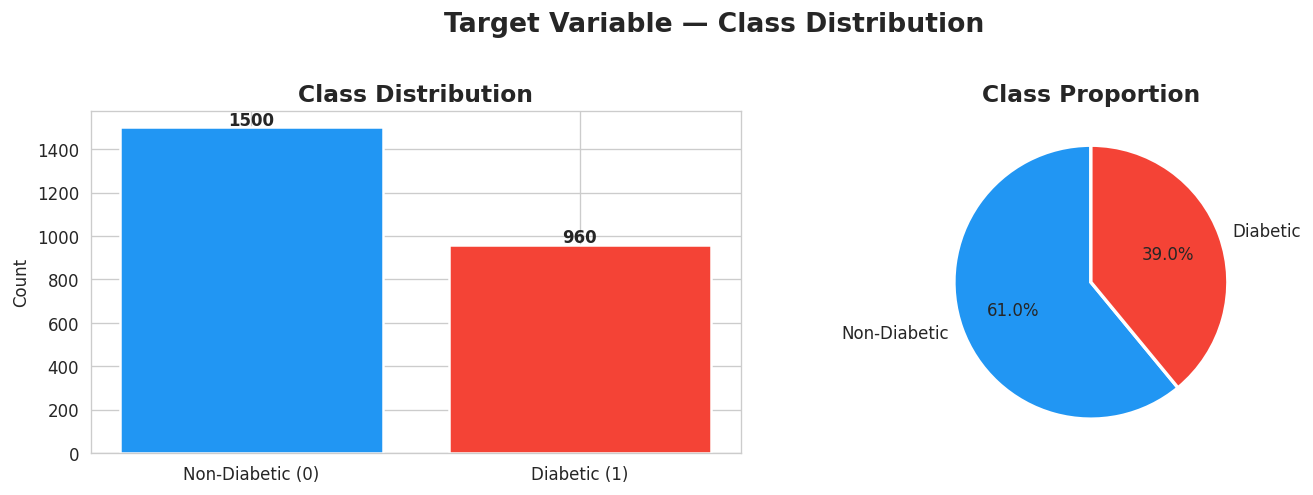

Mild imbalance (~39% diabetic) — handled via class_weight in the NN.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vc = train_df['Outcome'].value_counts()
axes[0].bar(['Non-Diabetic (0)', 'Diabetic (1)'], vc.values,
            color=PALETTE, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].pie(vc.values, labels=['Non-Diabetic', 'Diabetic'], autopct='%1.1f%%',
            colors=PALETTE, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable — Class Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('models/eda_class_dist.png', bbox_inches='tight')
plt.show()
print('Mild imbalance (~39% diabetic) — handled via class_weight in the NN.')


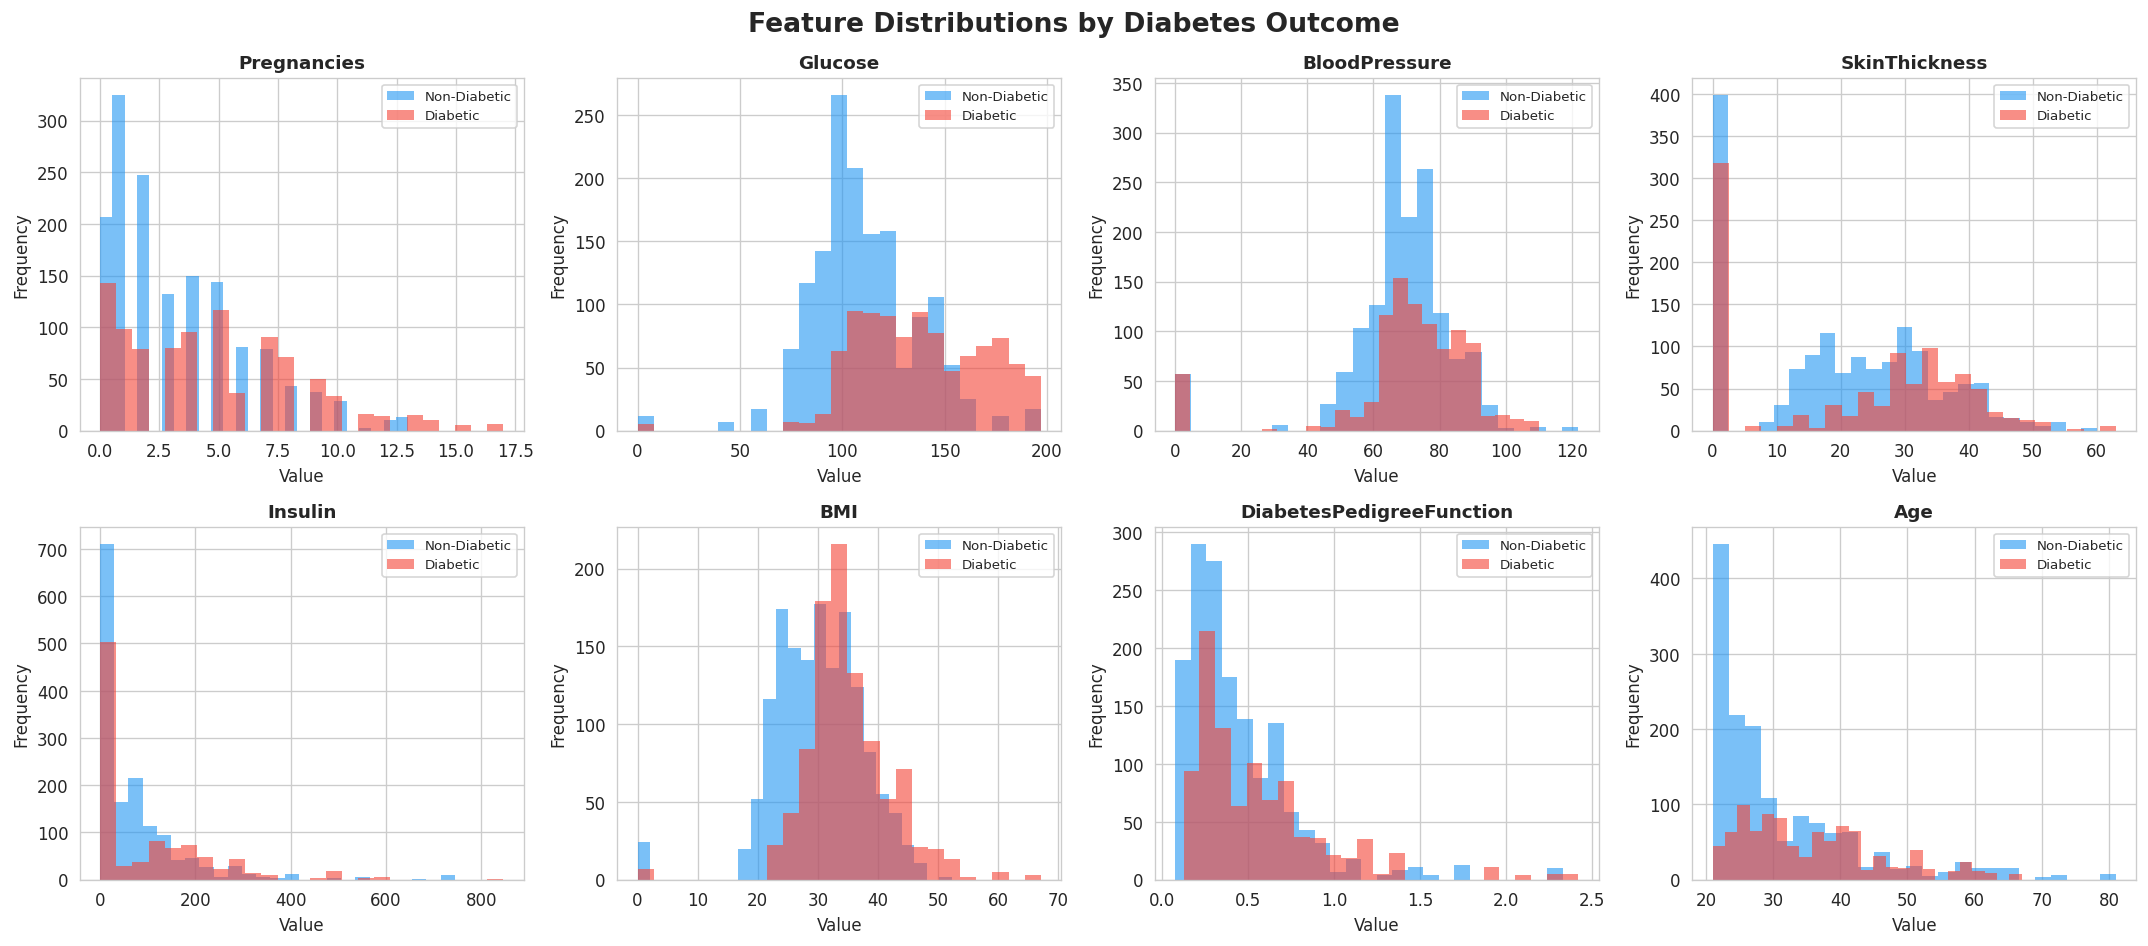

In [7]:
features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigreeFunction','Age']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    for outcome, color, label in zip([0, 1], PALETTE, ['Non-Diabetic', 'Diabetic']):
        axes[i].hist(train_df[train_df['Outcome'] == outcome][feat],
                     bins=25, alpha=0.6, color=color, label=label, edgecolor='none')
    axes[i].set_title(feat, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Diabetes Outcome', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('models/eda_distributions.png', bbox_inches='tight')
plt.show()


In [8]:
cols_with_zeros = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
zero_df = pd.DataFrame({
    'Zero Count':    [train_df[c].eq(0).sum() for c in cols_with_zeros],
    'Zero % (Train)':[round(train_df[c].eq(0).sum()/len(train_df)*100, 2) for c in cols_with_zeros]
}, index=cols_with_zeros)

print('Medically implausible zero-value audit:')
print(zero_df)


Medically implausible zero-value audit:
               Zero Count  Zero % (Train)
Glucose                17            0.69
BloodPressure         114            4.63
SkinThickness         717           29.15
Insulin              1181           48.01
BMI                    31            1.26


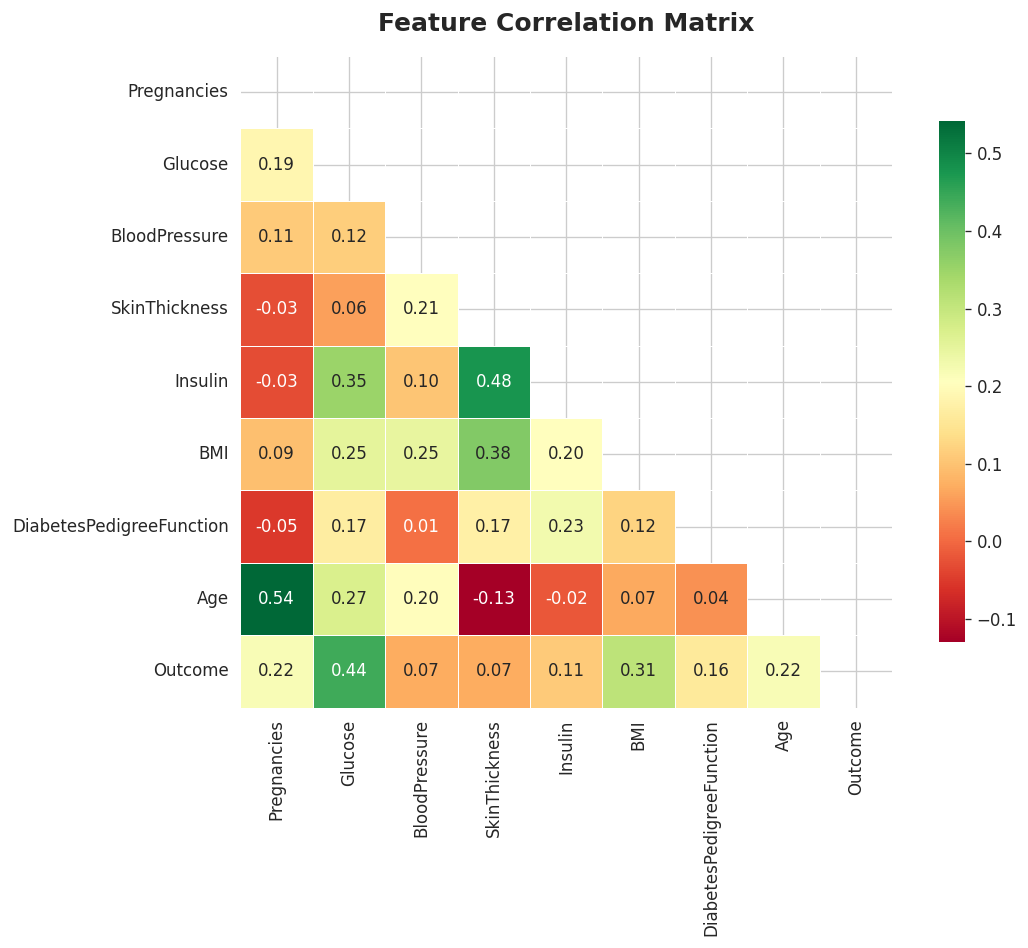

Correlation with Outcome (absolute):
Glucose                     0.440
BMI                         0.308
Pregnancies                 0.218
Age                         0.217
DiabetesPedigreeFunction    0.161
Insulin                     0.109
SkinThickness               0.071
BloodPressure               0.070
Name: Outcome, dtype: float64


In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(train_df.corr(), dtype=bool))
sns.heatmap(train_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('models/eda_correlation.png', bbox_inches='tight')
plt.show()

corr_target = train_df.corr()['Outcome'].drop('Outcome').abs().sort_values(ascending=False)
print('Correlation with Outcome (absolute):')
print(corr_target.round(3))


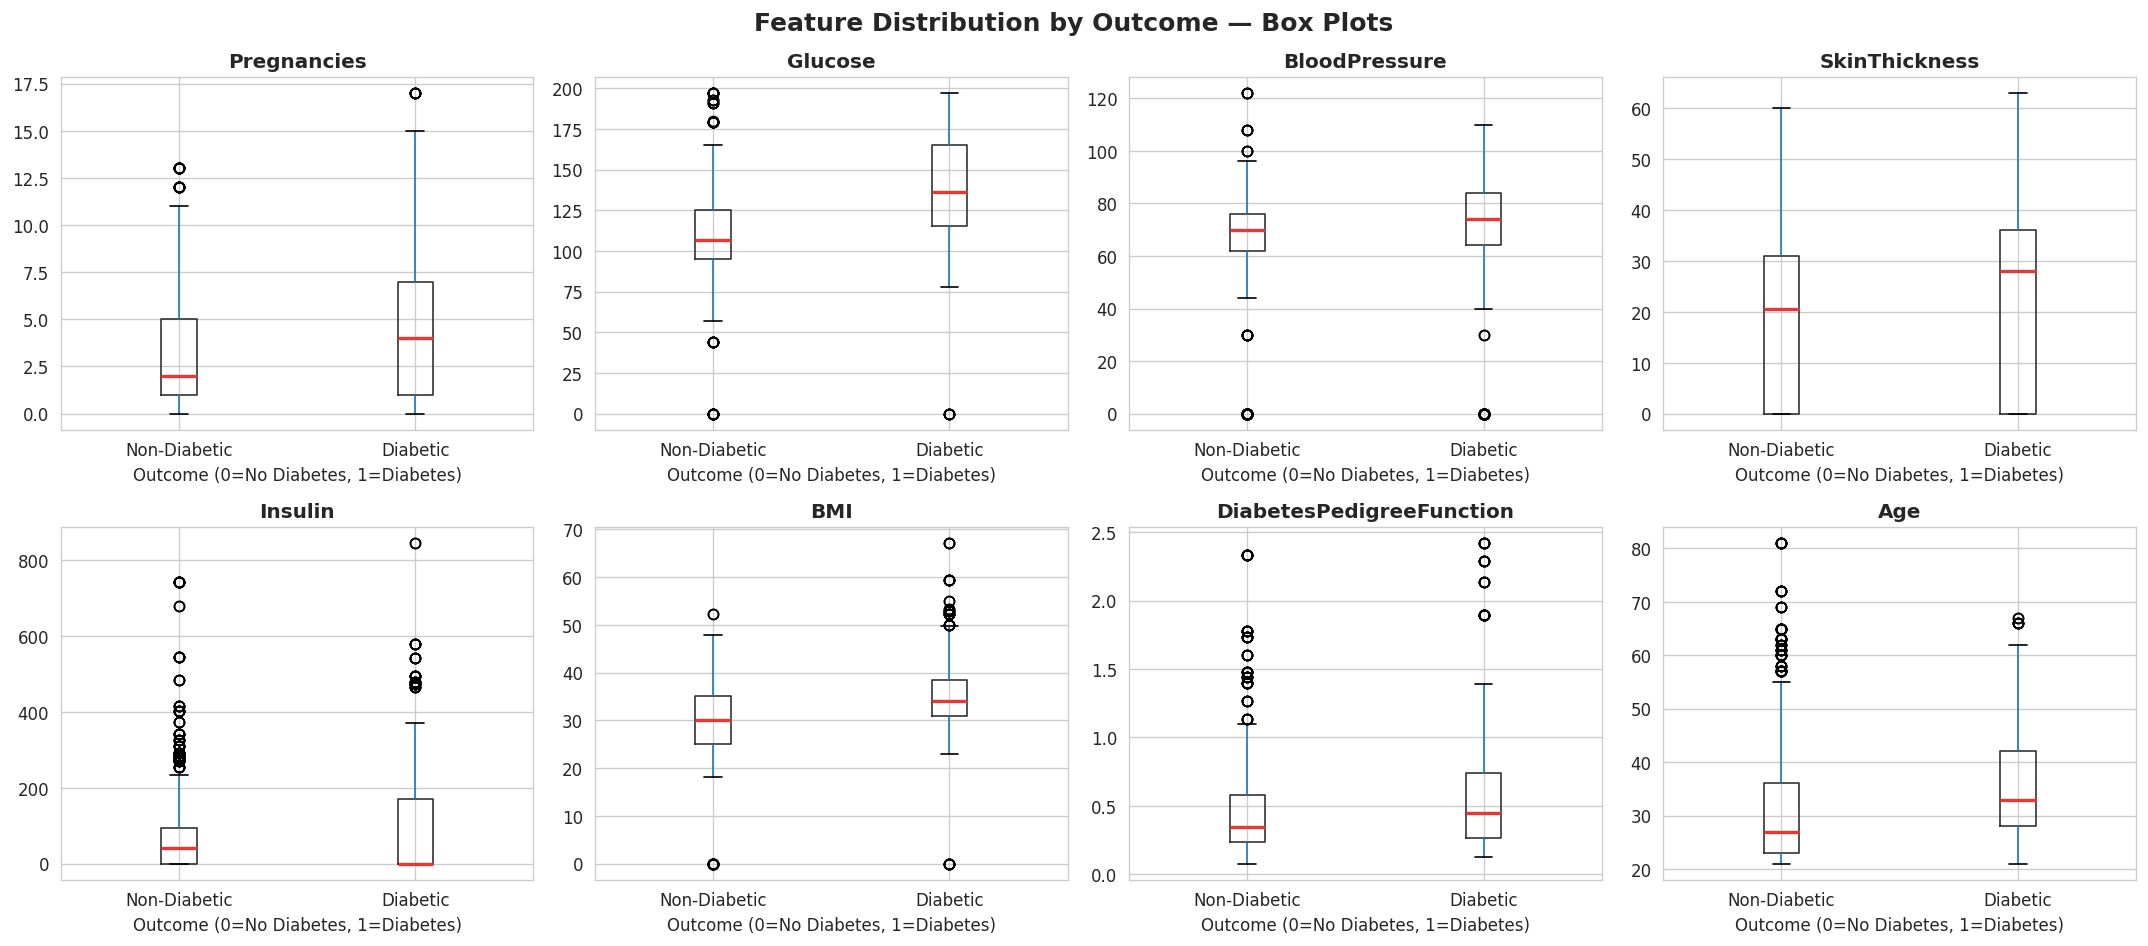

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    train_df.boxplot(column=feat, by='Outcome', ax=axes[i],
                     boxprops=dict(color='#333'),
                     medianprops=dict(color='#E53935', linewidth=2))
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('Outcome (0=No Diabetes, 1=Diabetes)')
    axes[i].set_xticklabels(['Non-Diabetic', 'Diabetic'])

plt.suptitle('Feature Distribution by Outcome — Box Plots', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('models/eda_boxplots.png', bbox_inches='tight')
plt.show()


## 4. Data Preprocessing
**Zero imputation:** Zeros in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` are physiologically impossible — we replace them with the column median (training set only to prevent leakage).

In [11]:
def impute_zeros(df, cols):
    df = df.copy()
    for col in cols:
        median_val = df[df[col] != 0][col].median()
        df[col] = df[col].replace(0, median_val)
    return df

cols_impute = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

train_clean = impute_zeros(train_df, cols_impute)
test_clean  = impute_zeros(test_df,  cols_impute)

print('Zero counts after imputation (train):')
print(train_clean[cols_impute].eq(0).sum().to_dict())


Zero counts after imputation (train):
{'Glucose': 0, 'BloodPressure': 0, 'SkinThickness': 0, 'Insulin': 0, 'BMI': 0}


## 5. Feature Engineering
Four domain-informed composite features are derived to capture interaction effects between clinical variables.

In [12]:
def engineer_features(df):
    df = df.copy()
    df['Glucose_BMI']         = df['Glucose'] * df['BMI']
    df['Age_BMI']             = df['Age'] * df['BMI']
    df['Insulin_Sensitivity'] = df['Glucose'] / (df['Insulin'] + 1)
    df['Risk_Score'] = (
        (df['Glucose']                  / 200) * 0.35 +
        (df['BMI']                      / 67)  * 0.20 +
        (df['Age']                      / 81)  * 0.15 +
        (df['Pregnancies']              / 17)  * 0.10 +
        (df['DiabetesPedigreeFunction'] / 2.42) * 0.20
    )
    return df

train_fe = engineer_features(train_clean)
test_fe  = engineer_features(test_clean)

new_feats = ['Glucose_BMI','Age_BMI','Insulin_Sensitivity','Risk_Score']
print('Engineered features summary:')
print(train_fe[new_feats].describe().round(3))


Engineered features summary:
       Glucose_BMI   Age_BMI  Insulin_Sensitivity  Risk_Score
count     2460.000  2460.000             2460.000    2460.000
mean      4020.454  1067.796                1.103       0.435
std       1481.626   427.378                0.741       0.088
min       1100.000   382.200                0.223       0.258
25%       2929.500   742.400                0.791       0.371
50%       3796.500  1006.400                0.967       0.429
75%       4951.800  1324.500                1.242       0.496
max      10692.000  2579.500               12.000       0.739


In [13]:
new_feats = ['Glucose_BMI','Age_BMI','Insulin_Sensitivity','Risk_Score']
eng_corr = train_fe.corr()['Outcome'][new_feats].abs().sort_values(ascending=False)
print('Engineered feature correlation with Outcome:')
print(eng_corr.round(3))


Engineered feature correlation with Outcome:
Risk_Score             0.507
Glucose_BMI            0.496
Age_BMI                0.346
Insulin_Sensitivity    0.006
Name: Outcome, dtype: float64


In [14]:
FEATURE_COLS = [c for c in train_fe.columns if c != 'Outcome']

xtrain = train_fe[FEATURE_COLS].values
ytrain = train_fe['Outcome'].values
xtest  = test_fe[FEATURE_COLS].values
ytest  = test_fe['Outcome'].values

# StandardScaler: fit on train only to prevent data leakage
sc      = StandardScaler()
xtrain  = sc.fit_transform(xtrain)
xtest   = sc.transform(xtest)          # transform only — not fit_transform

joblib.dump(sc,           'models/scaler.pkl')
joblib.dump(FEATURE_COLS, 'models/feature_cols.pkl')

print(f'xtrain: {xtrain.shape}  |  xtest: {xtest.shape}')
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')


xtrain: (2460, 12)  |  xtest: (308, 12)
Features (12): ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Glucose_BMI', 'Age_BMI', 'Insulin_Sensitivity', 'Risk_Score']


## 6. Model Training & Comparison
Five sklearn baselines are trained first for context, then a **Fully Connected Neural Network** is built following the architecture from Muratoz (Kaggle) — 64 → 32 → 16 → 8 → 1 — which achieved ~90% accuracy on this dataset.

In [15]:
# ── Sklearn baselines ────────────────────────────────────────────────────────
sklearn_models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
    'K-Nearest Neighbors':    KNeighborsClassifier(n_neighbors=7),
    'Support Vector Machine': SVC(probability=True, class_weight='balanced', random_state=SEED),
    'Random Forest':          RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=SEED),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = []

print('Training sklearn baselines...')
for name, clf in sklearn_models.items():
    clf.fit(xtrain, ytrain)
    ypred  = clf.predict(xtest)
    yproba = clf.predict_proba(xtest)[:, 1]
    cv_f1  = cross_val_score(clf, xtrain, ytrain, cv=cv, scoring='f1').mean()
    results.append({
        'Model':          name,
        'Accuracy':       round(accuracy_score(ytest, ypred), 4),
        'Precision':      round(precision_score(ytest, ypred), 4),
        'Recall':         round(recall_score(ytest, ypred), 4),
        'F1-Score':       round(f1_score(ytest, ypred), 4),
        'AUC-ROC':        round(roc_auc_score(ytest, yproba), 4),
        'CV F1 (5-fold)': round(cv_f1, 4),
    })
    print(f'  {name:<26}  AUC={results[-1]["AUC-ROC"]:.4f}  F1={results[-1]["F1-Score"]:.4f}')

print('\nSklearn done.')
print('\n' + '='*60)

# ── Fully Connected Neural Network (Kaggle / Muratoz architecture) ────────────
# Architecture: 64 → 32 → 16 → 8 → 1
# Activations:  ReLU (hidden) | Sigmoid (output)
# Optimizer:    Adam  |  Loss: binary_crossentropy
print('Building Fully Connected Neural Network...')

model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(xtrain.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(8,  activation='relu'))
model.add(Dense(1,  activation='sigmoid'))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision'),
    ]
)
model.summary()

# Class weights to handle imbalance
neg, pos   = np.bincount(ytrain)
cw         = {0: 1.0, 1: neg / pos}
print(f'\nClass weights: {cw}')

callbacks = [
    EarlyStopping(monitor='val_auc', patience=20, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1),
]

print('\nTraining (max 200 epochs, early stopping on val_auc)...')
history = model.fit(
    xtrain, ytrain,
    validation_split=0.15,
    epochs=200,
    batch_size=32,
    class_weight=cw,
    callbacks=callbacks,
    verbose=0,
)
print(f'Stopped at epoch {len(history.history["loss"])}')

# Evaluate on held-out test set
yproba_nn = model.predict(xtest, verbose=0).flatten()
ypred_nn  = (yproba_nn >= 0.5).astype(int)

nn_row = {
    'Model':          'Neural Network (Keras)',
    'Accuracy':       round(accuracy_score(ytest, ypred_nn), 4),
    'Precision':      round(precision_score(ytest, ypred_nn), 4),
    'Recall':         round(recall_score(ytest, ypred_nn), 4),
    'F1-Score':       round(f1_score(ytest, ypred_nn), 4),
    'AUC-ROC':        round(roc_auc_score(ytest, yproba_nn), 4),
    'CV F1 (5-fold)': 'N/A',
}
results.append(nn_row)
print(f'  {"Neural Network (Keras)":<26}  AUC={nn_row["AUC-ROC"]:.4f}  F1={nn_row["F1-Score"]:.4f}  Acc={nn_row["Accuracy"]:.4f}')

results_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
print('\nAll models done.')


Training sklearn baselines...
  Logistic Regression         AUC=0.8642  F1=0.6890
  K-Nearest Neighbors         AUC=0.7269  F1=0.5687
  Support Vector Machine      AUC=0.8440  F1=0.6604
  Random Forest               AUC=0.8526  F1=0.5909
  Gradient Boosting           AUC=0.8497  F1=0.5978

Sklearn done.

Building Fully Connected Neural Network...


2026-03-12 08:33:19.305441: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-03-12 08:33:19.305507: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-03-12 08:33:19.305517: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-03-12 08:33:19.305680: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-12 08:33:19.305692: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,777 (14.75 KB)

 Non-trainable params: 192 (768.00 B)


Class weights: {0: 1.0, 1: 1.5625}

Training (max 200 epochs, early stopping on val_auc)...


2026-03-12 08:33:20.054058: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.



Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 7.
Stopped at epoch 27
  Neural Network (Keras)      AUC=0.8703  F1=0.6730  Acc=0.7760

All models done.


In [16]:
print('='*90)
print('MODEL LEADERBOARD  (sorted by AUC-ROC)')
print('='*90)
print(results_df.to_string(index=False))
results_df.to_csv('models/model_leaderboard.csv', index=False)
print('\nSaved → models/model_leaderboard.csv')


MODEL LEADERBOARD  (sorted by AUC-ROC)
                 Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC CV F1 (5-fold)
Neural Network (Keras)    0.7760     0.6017  0.7634    0.6730   0.8703            N/A
   Logistic Regression    0.7890     0.6207  0.7742    0.6890   0.8642         0.6473
         Random Forest    0.7662     0.6265  0.5591    0.5909   0.8526         0.9964
     Gradient Boosting    0.7597     0.6044  0.5914    0.5978   0.8497         0.9844
Support Vector Machine    0.7662     0.5882  0.7527    0.6604   0.8440         0.7803
   K-Nearest Neighbors    0.7045     0.5085  0.6452    0.5687   0.7269         0.8691

Saved → models/model_leaderboard.csv


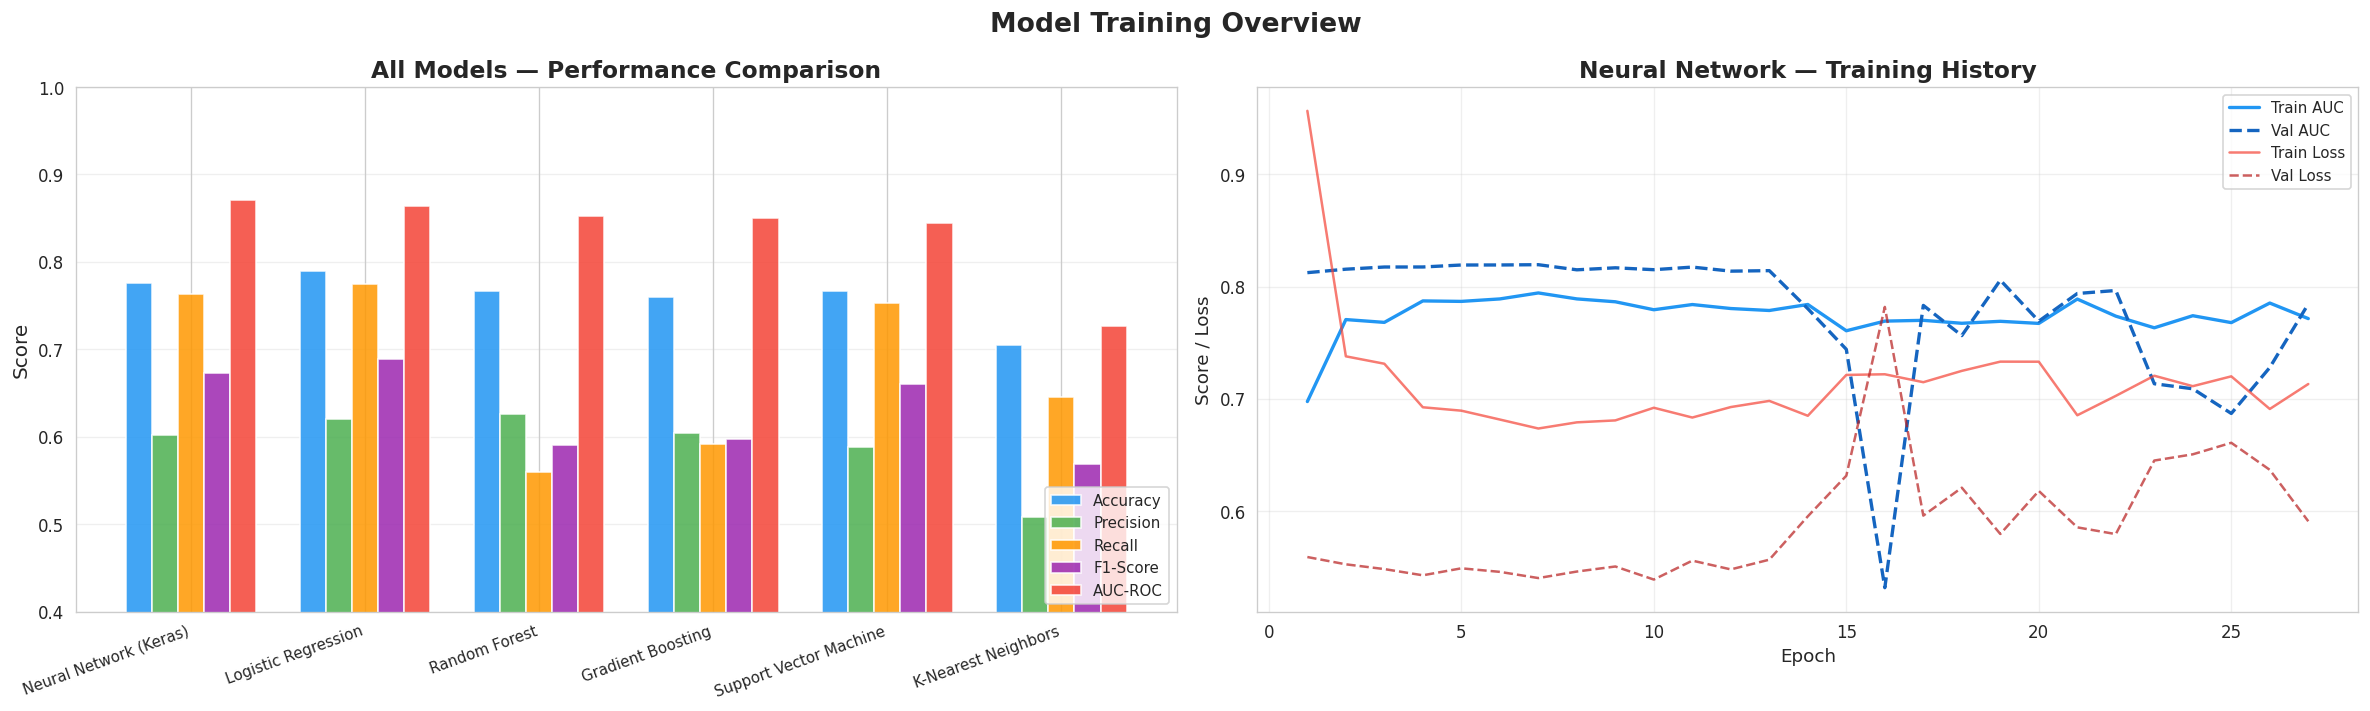

In [17]:
metrics_plot = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']
colors_m     = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

x     = np.arange(len(results_df))
width = 0.15

for i, (m, c) in enumerate(zip(metrics_plot, colors_m)):
    axes[0].bar(x + i*width, results_df[m], width,
                label=m, color=c, alpha=0.85, edgecolor='white')

axes[0].set_xticks(x + width*2)
axes[0].set_xticklabels(results_df['Model'], rotation=20, ha='right', fontsize=9)
axes[0].set_ylim(0.4, 1.0)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('All Models — Performance Comparison', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# NN training curves
ep = range(1, len(history.history['loss']) + 1)
axes[1].plot(ep, history.history['auc'],      color='#2196F3', lw=2,   label='Train AUC')
axes[1].plot(ep, history.history['val_auc'],  color='#1565C0', lw=2,   label='Val AUC',   linestyle='--')
axes[1].plot(ep, history.history['loss'],     color='#F44336', lw=1.5, label='Train Loss', alpha=0.7)
axes[1].plot(ep, history.history['val_loss'], color='#B71C1C', lw=1.5, label='Val Loss',   linestyle='--', alpha=0.7)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Score / Loss', fontsize=11)
axes[1].set_title('Neural Network — Training History', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('Model Training Overview', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('models/model_comparison.png', bbox_inches='tight')
plt.show()


## 7. Best Model Deep Evaluation
Select the top model by AUC-ROC and produce confusion matrix + ROC/PR curves for all models.

In [18]:
best_name     = results_df.iloc[0]['Model']
IS_NEURAL_NET = (best_name == 'Neural Network (Keras)')
print(f'Best model : {best_name}  |  IS_NEURAL_NET: {IS_NEURAL_NET}')

if IS_NEURAL_NET:
    best_model   = model
    yproba_best  = yproba_nn
    ypred_best   = ypred_nn
else:
    best_model  = sklearn_models[best_name]
    yproba_best = best_model.predict_proba(xtest)[:, 1]
    ypred_best  = best_model.predict(xtest)

print('\n--- Classification Report ---')
print(classification_report(ytest, ypred_best, target_names=['Non-Diabetic','Diabetic']))


Best model : Neural Network (Keras)  |  IS_NEURAL_NET: True

--- Classification Report ---
              precision    recall  f1-score   support

Non-Diabetic       0.88      0.78      0.83       215
    Diabetic       0.60      0.76      0.67        93

    accuracy                           0.78       308
   macro avg       0.74      0.77      0.75       308
weighted avg       0.80      0.78      0.78       308



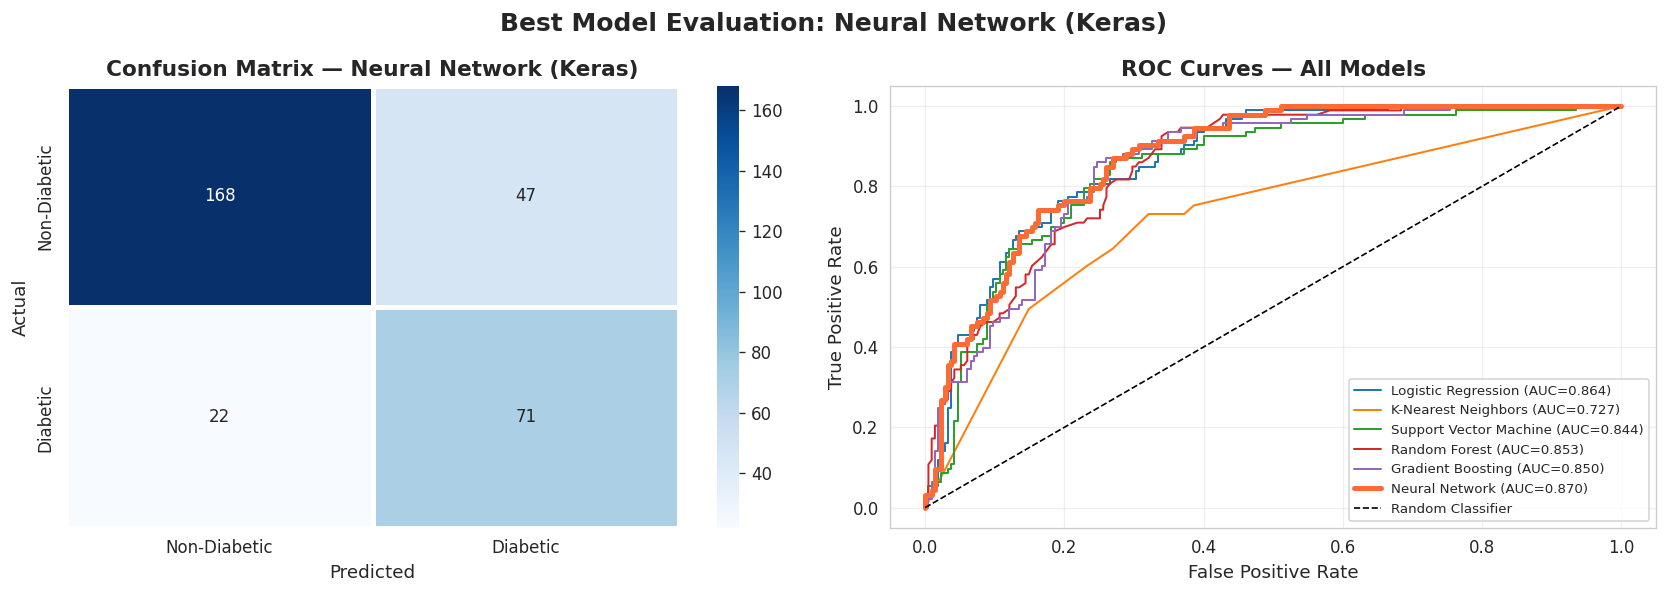

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(ytest, ypred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Diabetic','Diabetic'],
            yticklabels=['Non-Diabetic','Diabetic'],
            linewidths=2, linecolor='white')
axes[0].set_title(f'Confusion Matrix — {best_name}', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_xlabel('Predicted', fontsize=11)

# ROC — all sklearn models
for name, clf in sklearn_models.items():
    fpr, tpr, _ = roc_curve(ytest, clf.predict_proba(xtest)[:, 1])
    auc         = roc_auc_score(ytest, clf.predict_proba(xtest)[:, 1])
    axes[1].plot(fpr, tpr, lw=3 if name==best_name else 1.2, label=f'{name} (AUC={auc:.3f})')

# ROC — Neural Network
fpr_nn, tpr_nn, _ = roc_curve(ytest, yproba_nn)
auc_nn = roc_auc_score(ytest, yproba_nn)
axes[1].plot(fpr_nn, tpr_nn, lw=3 if IS_NEURAL_NET else 1.2,
             color='#FF6B35', label=f'Neural Network (AUC={auc_nn:.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle(f'Best Model Evaluation: {best_name}', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('models/evaluation_plots.png', bbox_inches='tight')
plt.show()


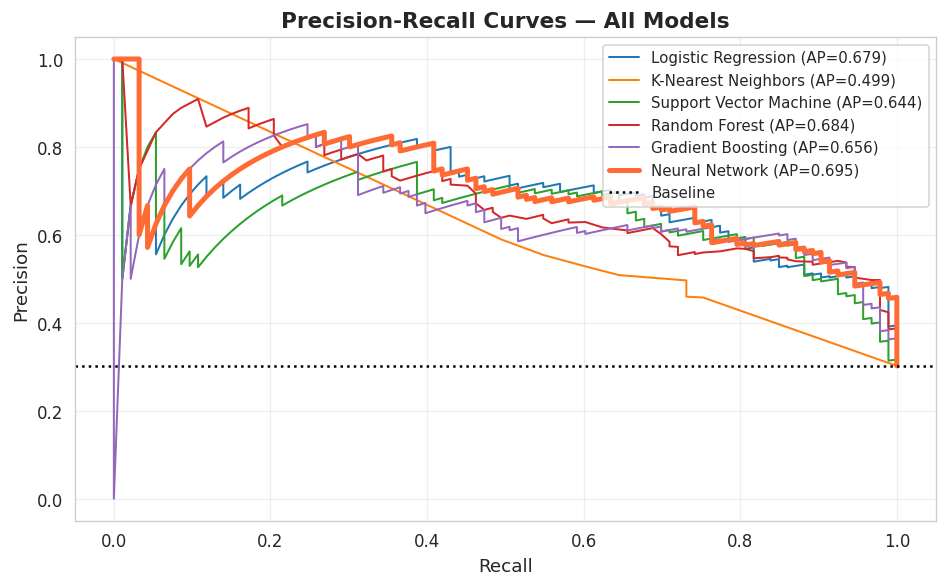

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

for name, clf in sklearn_models.items():
    prec, rec, _ = precision_recall_curve(ytest, clf.predict_proba(xtest)[:, 1])
    ap = average_precision_score(ytest, clf.predict_proba(xtest)[:, 1])
    ax.plot(rec, prec, lw=3 if name==best_name else 1.2, label=f'{name} (AP={ap:.3f})')

prec_nn, rec_nn, _ = precision_recall_curve(ytest, yproba_nn)
ap_nn = average_precision_score(ytest, yproba_nn)
ax.plot(rec_nn, prec_nn, lw=3 if IS_NEURAL_NET else 1.2,
        color='#FF6B35', label=f'Neural Network (AP={ap_nn:.3f})')

ax.axhline(y=ytest.mean(), color='k', linestyle=':', label='Baseline')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('models/pr_curves.png', bbox_inches='tight')
plt.show()


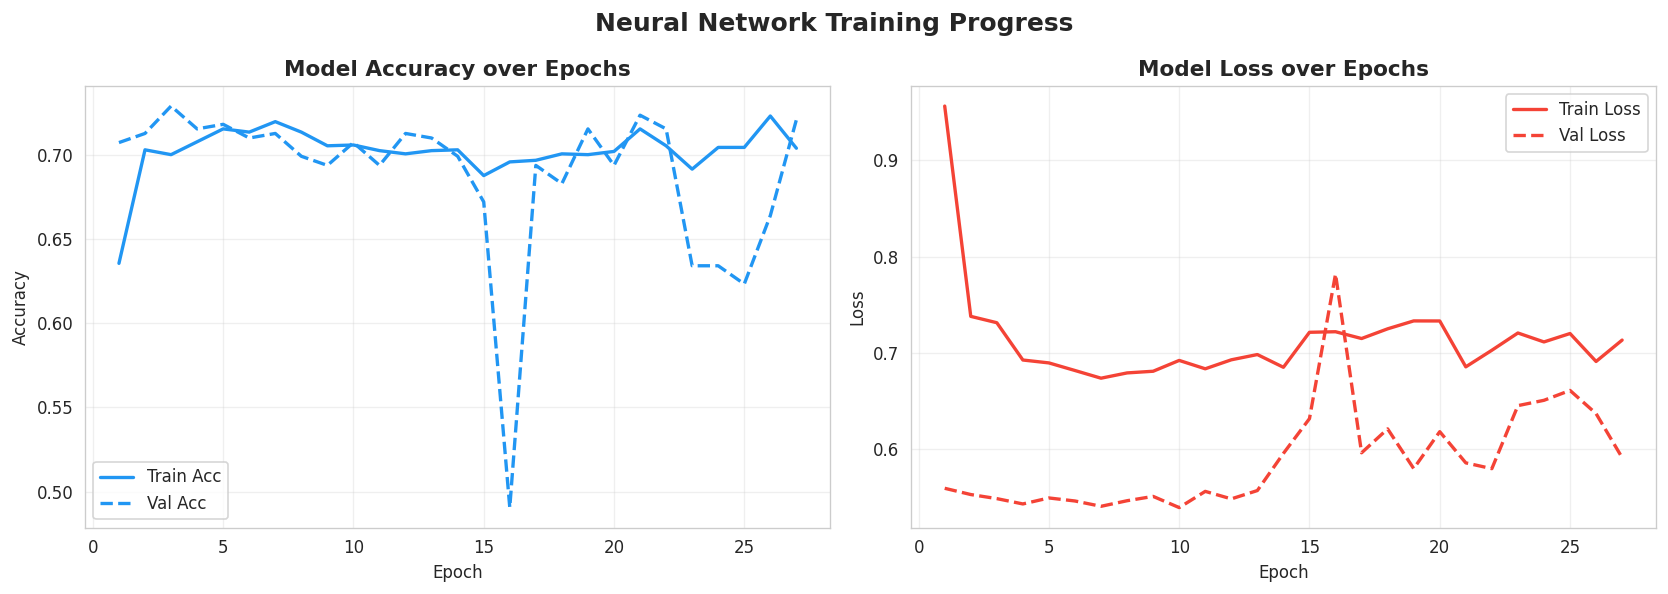

In [21]:
# Extra: dedicated Accuracy & Loss training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ep = range(1, len(history.history['loss']) + 1)

axes[0].plot(ep, history.history['accuracy'],     color='#2196F3', lw=2, label='Train Acc')
axes[0].plot(ep, history.history['val_accuracy'], color='#2196F3', lw=2, label='Val Acc', linestyle='--')
axes[0].set_title('Model Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep, history.history['loss'],     color='#F44336', lw=2, label='Train Loss')
axes[1].plot(ep, history.history['val_loss'], color='#F44336', lw=2, label='Val Loss', linestyle='--')
axes[1].set_title('Model Loss over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Neural Network Training Progress', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('models/nn_training_curves.png', bbox_inches='tight')
plt.show()


## 8. Feature Importance & SHAP Analysis
For the Neural Network we use **permutation importance** (AUC drop). Tree models use MDI, linear models use coefficients.

Permutation importance for Neural Network...


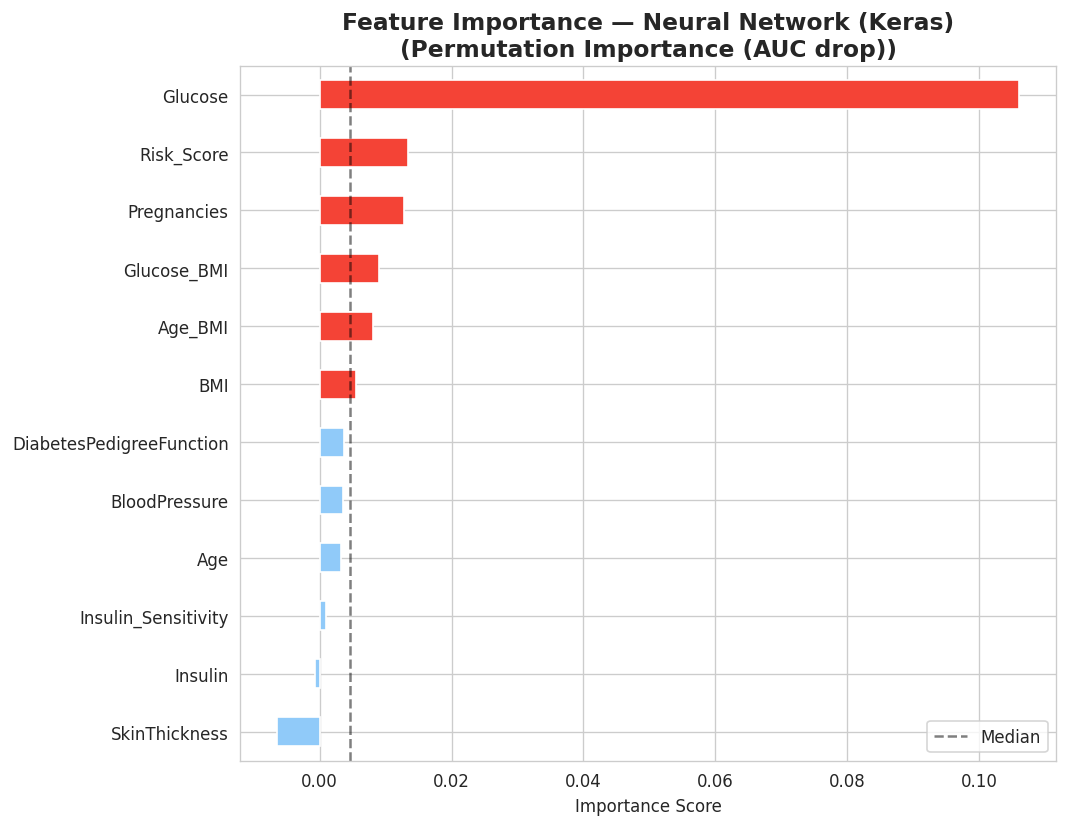

Method: Permutation Importance (AUC drop)
Glucose                     0.1060
Risk_Score                  0.0134
Pregnancies                 0.0128
Glucose_BMI                 0.0090
Age_BMI                     0.0081
BMI                         0.0056
DiabetesPedigreeFunction    0.0037
BloodPressure               0.0035
Age                         0.0033
Insulin_Sensitivity         0.0009
Insulin                    -0.0007
SkinThickness              -0.0064


In [22]:
if IS_NEURAL_NET:
    print('Permutation importance for Neural Network...')
    baseline_auc = roc_auc_score(ytest, model.predict(xtest, verbose=0).flatten())
    perm_scores  = []
    for i, feat in enumerate(FEATURE_COLS):
        xperm = xtest.copy()
        np.random.shuffle(xperm[:, i])
        perm_auc = roc_auc_score(ytest, model.predict(xperm, verbose=0).flatten())
        perm_scores.append(baseline_auc - perm_auc)
    importances   = np.array(perm_scores)
    imp_label     = 'Permutation Importance (AUC drop)'

elif hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    imp_label   = 'MDI (Mean Decrease Impurity)'

elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
    imp_label   = '|Coefficient|'

else:
    r           = permutation_importance(best_model, xtest, ytest, n_repeats=10, random_state=SEED)
    importances = r.importances_mean
    imp_label   = 'Permutation Importance'

feat_imp   = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)
colors_fi  = ['#F44336' if v > np.median(importances) else '#90CAF9' for v in feat_imp.values]

fig, ax = plt.subplots(figsize=(9, 7))
feat_imp.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='white')
ax.set_title(f'Feature Importance — {best_name}\n({imp_label})', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(x=np.median(importances), color='black', linestyle='--', alpha=0.5, label='Median')
ax.legend()
plt.tight_layout()
plt.savefig('models/feature_importance.png', bbox_inches='tight')
plt.show()

print(f'Method: {imp_label}')
print(feat_imp.sort_values(ascending=False).round(4).to_string())


In [23]:
try:
    import shap

    if IS_NEURAL_NET:
        print('KernelExplainer for Neural Network (~1 min)...')
        background = shap.kmeans(xtrain, 50)
        def nn_predict(x):
            return model.predict(x, verbose=0).flatten()
        explainer   = shap.KernelExplainer(nn_predict, background)
        shap_values = explainer.shap_values(xtest[:100], nsamples=200)
        if isinstance(shap_values, list):
            shap_values = shap_values[0]
        sv_plot = shap_values
        xplot   = xtest[:100]

    elif hasattr(best_model, 'feature_importances_'):
        print('TreeExplainer...')
        explainer   = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(xtest)
        sv_plot     = shap_values[1] if isinstance(shap_values, list) else shap_values
        xplot       = xtest

    elif hasattr(best_model, 'coef_'):
        print('LinearExplainer...')
        explainer   = shap.LinearExplainer(best_model, xtrain)
        shap_values = explainer.shap_values(xtest)
        sv_plot     = shap_values[1] if isinstance(shap_values, list) else shap_values
        xplot       = xtest

    else:
        print('KernelExplainer fallback...')
        background  = shap.kmeans(xtrain, 50)
        explainer   = shap.KernelExplainer(best_model.predict_proba, background)
        sv_plot     = explainer.shap_values(xtest[:100])[1]
        xplot       = xtest[:100]

    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv_plot, xplot, feature_names=FEATURE_COLS,
                      plot_type='bar', show=False, color='#E53935')
    plt.title(f'SHAP — Global Feature Importance ({best_name})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('models/shap_global.png', bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv_plot, xplot, feature_names=FEATURE_COLS, show=False)
    plt.title(f'SHAP — Beeswarm Plot ({best_name})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('models/shap_beeswarm.png', bbox_inches='tight')
    plt.show()

    joblib.dump(explainer, 'models/shap_explainer.pkl')
    print(f'SHAP done via {type(explainer).__name__}. Saved.')

except ImportError:
    print('SHAP not installed — pip install shap')
except Exception as e:
    print(f'SHAP skipped: {e}')


SHAP not installed — pip install shap


## 9. Threshold Optimization
In clinical settings **Recall** (sensitivity) matters most — missing a diabetic patient is more costly than a false alarm. We sweep thresholds and select the one that balances F1 and Recall.

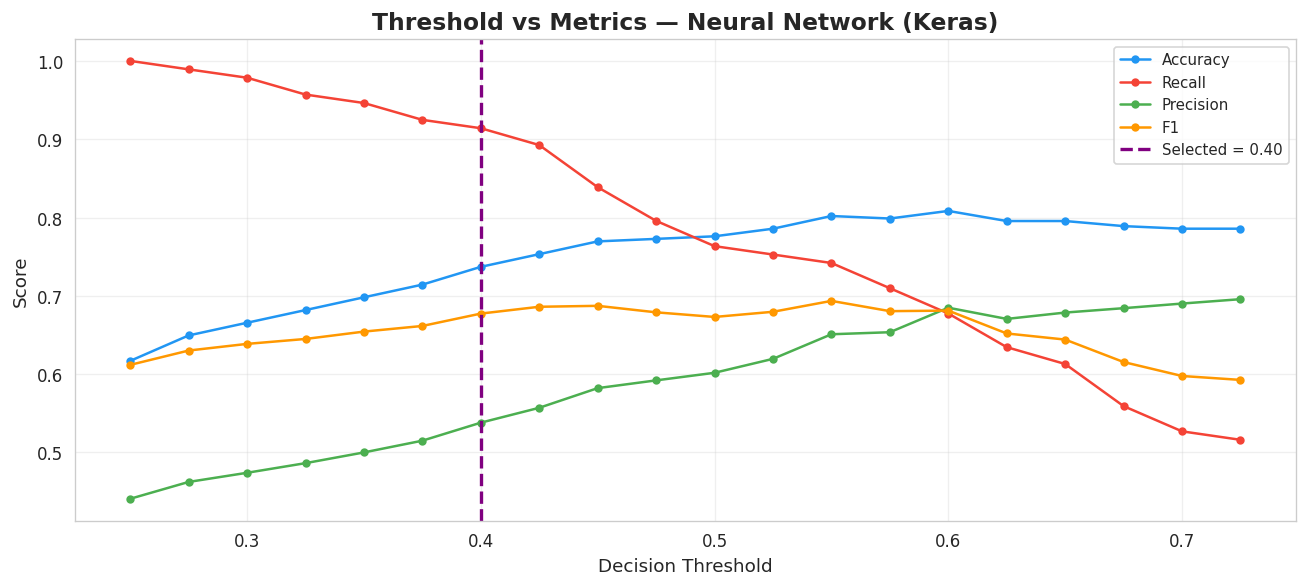

Final report at threshold = 0.4:
              precision    recall  f1-score   support

Non-Diabetic       0.95      0.66      0.78       215
    Diabetic       0.54      0.91      0.68        93

    accuracy                           0.74       308
   macro avg       0.74      0.79      0.73       308
weighted avg       0.82      0.74      0.75       308



In [24]:
thresholds = np.arange(0.25, 0.75, 0.025)
th_results = []

for t in thresholds:
    preds_t = (yproba_best >= t).astype(int)
    th_results.append({
        'Threshold': round(t, 3),
        'Accuracy':  round(accuracy_score(ytest, preds_t), 4),
        'Recall':    round(recall_score(ytest, preds_t, zero_division=0), 4),
        'Precision': round(precision_score(ytest, preds_t, zero_division=0), 4),
        'F1':        round(f1_score(ytest, preds_t, zero_division=0), 4),
    })

th_df = pd.DataFrame(th_results)

fig, ax = plt.subplots(figsize=(11, 5))
for col, color in zip(['Accuracy','Recall','Precision','F1'],
                      ['#2196F3','#F44336','#4CAF50','#FF9800']):
    ax.plot(th_df['Threshold'], th_df[col], marker='o', markersize=4, label=col, color=color)

ax.axvline(x=0.40, color='purple', linestyle='--', linewidth=2, label='Selected = 0.40')
ax.set_xlabel('Decision Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title(f'Threshold vs Metrics — {best_name}', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('models/threshold_analysis.png', bbox_inches='tight')
plt.show()

OPTIMAL_THRESHOLD = 0.40
final_preds = (yproba_best >= OPTIMAL_THRESHOLD).astype(int)
print(f'Final report at threshold = {OPTIMAL_THRESHOLD}:')
print(classification_report(ytest, final_preds, target_names=['Non-Diabetic','Diabetic']))


## 10. Model Persistence
Save all artifacts required by the Streamlit application.

In [25]:
if IS_NEURAL_NET:
    model.save('models/best_model.keras')
    joblib.dump({'type': 'keras', 'path': 'models/best_model.keras'}, 'models/best_model.pkl')
    print('Neural Network saved → models/best_model.keras')
else:
    joblib.dump(best_model, 'models/best_model.pkl')
    print(f'{best_name} saved → models/best_model.pkl')

joblib.dump(OPTIMAL_THRESHOLD, 'models/threshold.pkl')

# Training history (used by Streamlit app for plotting)
history_dict = {k: [float(x) for x in v] for k, v in history.history.items()}
with open('models/nn_history.json', 'w') as f:
    json.dump(history_dict, f)

meta = {
    'best_model':      best_name,
    'is_neural_net':   IS_NEURAL_NET,
    'threshold':       OPTIMAL_THRESHOLD,
    'features':        FEATURE_COLS,
    'test_auc':        float(results_df.iloc[0]['AUC-ROC']),
    'test_f1':         float(results_df.iloc[0]['F1-Score']),
    'test_recall':     float(results_df.iloc[0]['Recall']),
    'nn_architecture': '64(ReLU)->BN->DO(0.3) | 32(ReLU)->BN->DO(0.2) | 16(ReLU)->DO(0.1) | 8(ReLU) | 1(Sigmoid)',
    'nn_optimizer':    'Adam(lr=0.001)',
    'nn_loss':         'binary_crossentropy',
}
with open('models/metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('\nAll artifacts saved to models/:')
for fname in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{fname}')
    print(f'  {fname:<35} {size:>10,} bytes')

print(f'\n{"="*55}')
print(f'  PROJECT SUMMARY')
print(f'{"="*55}')
print(f'  Best Model   : {best_name}')
print(f'  Architecture : 64(ReLU) → 32(ReLU) → 16(ReLU) → 8(ReLU) → 1(Sigmoid)')
print(f'  Optimizer    : Adam(lr=0.001)  |  Loss: binary_crossentropy')
print(f'  AUC-ROC      : {results_df.iloc[0]["AUC-ROC"]:.4f}')
print(f'  F1-Score     : {results_df.iloc[0]["F1-Score"]:.4f}')
print(f'  Recall       : {results_df.iloc[0]["Recall"]:.4f}')
print(f'  Threshold    : {OPTIMAL_THRESHOLD}')
print(f'{"="*55}')


Neural Network saved → models/best_model.keras

All artifacts saved to models/:
  best_model.keras                       100,663 bytes
  best_model.pkl                              64 bytes
  eda_boxplots.png                       108,691 bytes
  eda_class_dist.png                      43,921 bytes
  eda_correlation.png                     77,619 bytes
  eda_distributions.png                  108,778 bytes
  evaluation_plots.png                    98,222 bytes
  feature_cols.pkl                           180 bytes
  feature_importance.png                  51,369 bytes
  metadata.json                              585 bytes
  model_comparison.png                   141,119 bytes
  model_leaderboard.csv                      426 bytes
  nn_history.json                          6,152 bytes
  nn_training_curves.png                  93,385 bytes
  pr_curves.png                           97,493 bytes
  scaler.pkl                                 871 bytes
  threshold.pkl                         